In [8]:
import numpy as np
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
import random
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import umap
import pandas as pd
from numpy import inf
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_score

d:\Tesis\icafs\icafs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
import opfython.math.general as g
import opfython.stream.parser as p
import opfython.stream.splitter as s
from opfython.models import SupervisedOPF
from opfython.stream import loader
from opfython.utils import logging

Load Dataset

In [11]:
df_cis = pd.read_csv('../data/cis_data.csv')
df_cacao = pd.read_csv(r'..\\data\\data_temp\\cacao.csv')
df_algarrobo = pd.read_csv(r'..\\data\\data_temp\\algarrobo.csv')
df_fruits_pures = pd.read_csv(r'../data/data_temp/MIR_Fruit_purees.csv')
df_fresh_meat = pd.read_csv(r'../data/data_temp/Fresh_meats.csv')
df_olive = pd.read_csv(r'../data/data_temp/Olive_Oils_Quadrum.csv')


df_x_cacao = df_cacao.iloc[:, 1:]
y_cacao = df_cacao.iloc[:, 0:1]
X_cacao = (df_x_cacao-df_x_cacao.min())/(df_x_cacao.max()-df_x_cacao.min())

unique_names_algarrobo = df_algarrobo['Labels'].unique()
algarrobo_x = df_algarrobo.loc[:, 'R':'REDVI']
y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
X_algarrobo = (algarrobo_x-algarrobo_x.min())/(algarrobo_x.max()-algarrobo_x.min())

cis_x = df_cis[['X', 'Y', 'X10', 'Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']]
y_cis = df_cis[['Result']]




unique_names_berry = df_fruits_pures["label"].unique()
fruits_pures_x = df_fruits_pures.iloc[:,1:]
y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
X_fruit_puree = (fruits_pures_x-fruits_pures_x.min())/(fruits_pures_x.max()-fruits_pures_x.min())


unique_names_meat = df_fresh_meat["meat"].unique()
meat_x = df_fresh_meat.iloc[:,4:]
y_meat = df_fresh_meat.iloc[:,0:1].replace(to_replace=unique_names_meat,value=range(0,len(unique_names_meat)))
X_meat =  (meat_x-meat_x.min())/(meat_x.max()-meat_x.min())

unique_names_olive = df_olive["Provenance"].unique()
olive_x = df_olive.iloc[:,3:]
y_olive = df_olive.iloc[:,2:3].replace(to_replace=unique_names_olive,value=range(0,len(unique_names_olive)))
X_olive =  (olive_x-olive_x.min())/(olive_x.max()-olive_x.min())

X_cis = (cis_x-cis_x.min())/(cis_x.max()-cis_x.min())
covering_array  = np.loadtxt(r'../data/coveringArray.csv', delimiter=",", dtype=int)



C:\Users\robma\AppData\Local\Temp\ipykernel_17420\1580072406.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
C:\Users\robma\AppData\Local\Temp\ipykernel_17420\1580072406.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
C:\Users\robma\AppData\Local\Temp\ipykernel_17420\1580072406.py:32: FutureWarning: Downcasting behavio

In [15]:
def cafs(ca,dataset_x,dataset_y, max_iter ,clasifier,print_logs=False):

  global_data_set = dataset_x
  global_max = 0
  max_iteartion = 0
  result_list_x = []
  result_list_y = []
  result_list_score = []
  num_rows = ca.shape[0]

  if len(dataset_x.columns) < ca.shape[1] :
    num_colums = len(dataset_x.columns)
  else:
    num_colums = ca.shape[1]

  initialTestTraining(result_list_score,result_list_x, result_list_y,dataset_x, dataset_y,clasifier)
  while max_iteartion < max_iter:

     lst_headers = global_data_set.columns.values.copy()
     max_score = 0.0
     mx_data_set = None
     #random.shuffle(lst_headers)
    
     for i in range(0,num_rows):
        lst_headers_to_select = []
        for j in range(0,num_colums ):
          if ca[i][j] == 1 :
              lst_headers_to_select.append(lst_headers[j])
        #with the list of headers to select get sub dat set of col with pandas
        if len(lst_headers_to_select) == 0:
            continue
        df_temp = dataset_x[lst_headers_to_select]
        score = cross_val_score(clasifier,df_temp.values, dataset_y.values.ravel(), cv=5, scoring='f1_macro')
        if score.mean() >= max_score :
            max_score = score.mean()
            mx_data_set = df_temp.copy()

     global_data_set = mx_data_set.copy()
     global_max = max_score
     if print_logs:
         print(f"best f1 score= {global_max}, iteration:{max_iteartion}, numbers features selected ={len(global_data_set.columns)},best features selected={', '.join(global_data_set)}" )

     num_colums  = len(global_data_set.columns)
     mx_data_set = None
     max_score = 0
     max_iteartion = max_iteartion  +1
     result_list_x.append(max_iteartion)
     result_list_y.append(len(global_data_set.columns))
     result_list_score.append(global_max)
  return result_list_x,result_list_y,result_list_score

def initialTestTraining(score_list, iter_list, feature_list ,X,y,clasifier):
    score = cross_val_score(clasifier,X, y.values.ravel(), cv=5, scoring='f1_macro')
    score_list.append(score.mean())
    feature_list.append(X.shape[1])
    iter_list.append(0)


In [14]:

from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


def plot_original_vs_reduced_umap(df_reduced_dataset,df_complete, y_dataset_integer,unique_classes):
    umap_3d = umap.UMAP(n_components=3)
    
    X_reduced_standarized = StandardScaler().fit_transform(df_reduced_dataset)
    X_complete_standarized  = StandardScaler().fit_transform(df_complete)
    
    reduced_umap = umap_3d.fit_transform(X_reduced_standarized)
    complete_umap = umap_3d.fit_transform(X_complete_standarized)
  
    fig = plt.figure(figsize=plt.figaspect(0.5))
    y_dataset_flatten = y_dataset_integer.values.ravel()

    print(unique_classes)
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    for i in range(0,len(unique_classes)): 
        indices = np.where(y_dataset_flatten == i)
        ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
    plt.legend()
    #ax.scatter(complete_umap[:,0], complete_umap[:,1], complete_umap[:,2], c=[sns.color_palette()[x] for x in y_dataset_flatten],marker = "v",label=unique_classes[0])
    
    ax = fig.add_subplot(1, 2, 2, projection='3d')
    for i in range(0,len(unique_classes)): 
        indices = np.where(y_dataset_flatten == i)
        ax.scatter(reduced_umap[indices,0], reduced_umap[indices,1], reduced_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])

    #ax.scatter(reduced_umap[:,0], reduced_umap[:,1], reduced_umap[:,2], c=[sns.color_palette()[x] for x in y_dataset_flatten],marker = "v",label=unique_classes[0])
    plt.legend()
    
    plt.show()
   

In [2]:
def  plot_results_for_covering_array(scores,feature,num_of_iterarion, path_to_save_image):
        color = 'tab:blue'
        res_scores = np.array(scores)
        res_features = np.array(feature)
        res_iter = np.array(num_of_iterarion)

        plt.figure(figsize=(11, 10))
        
        fig, ax1 = plt.subplots()
        barwidth = 0.4
        color = 'tab:red'
        ax1.set_xlabel('Iterations')
        ax1.set_ylabel('Number of features', color=color)
        #ax1.set_title("ICAFS Feature selection on the Cacao dataset")
        ax1.spines['top'].set_visible(False)
        ax1.bar(res_iter-0.2, res_features, color=color, width=barwidth)
        ax1.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax1.set_ylim(1,max(res_features)+3)
        ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
        #for i in range(len(res_iter)):
        #    ax1.text(i+1-0.2,    res_features[i], res_features[i],rotation='vertical')
        for bar in ax1.patches:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height}', fontsize=10,
                    ha='center', va='bottom', rotation=90)
            
        ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
        color = 'tab:blue'
        ax2.set_ylabel('F1_score', color=color)
        ax2.bar(res_iter+0.2, res_scores, color=color, width=barwidth)
        ax2.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax2.set_ylim(min(res_scores)-0.001, max(res_scores)+0.001)

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        #for i in range(len(res_iter)):
        #    ax2.text(i+1, res_scores[i], f"{res_scores[i]:.3f}",rotation='vertical')

        for bar in ax2.patches:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height:.2f}', fontsize=10,
                    ha='center', va='bottom', rotation=90)

        #plt.title('ICAFS Feature selection for Cacao Dataset with OPF', y=-0.20)
        plt.gca().set_frame_on(False)
        plt.savefig(path_to_save_image)

# CAFS KNN

best f1 score= 0.8578955297717368, iteration:0, numbers features selected =699,best features selected=1100, 1101, 1102, 1105, 1107, 1108, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1119, 1120, 1122, 1123, 1124, 1127, 1131, 1132, 1133, 1139, 1142, 1144, 1145, 1146, 1147, 1152, 1155, 1156, 1157, 1158, 1161, 1162, 1166, 1168, 1169, 1171, 1172, 1173, 1178, 1179, 1180, 1181, 1182, 1187, 1190, 1191, 1194, 1198, 1199, 1200, 1201, 1203, 1204, 1206, 1207, 1208, 1209, 1210, 1212, 1214, 1215, 1216, 1219, 1222, 1223, 1227, 1228, 1230, 1234, 1235, 1236, 1239, 1240, 1243, 1245, 1249, 1250, 1251, 1253, 1254, 1258, 1261, 1264, 1265, 1267, 1268, 1270, 1275, 1277, 1281, 1283, 1284, 1290, 1291, 1295, 1297, 1298, 1302, 1304, 1305, 1306, 1309, 1310, 1311, 1312, 1315, 1316, 1317, 1319, 1320, 1322, 1323, 1324, 1325, 1327, 1330, 1333, 1334, 1336, 1337, 1339, 1340, 1341, 1344, 1348, 1349, 1350, 1352, 1354, 1355, 1358, 1359, 1363, 1364, 1365, 1367, 1370, 1371, 1372, 1375, 1376, 1378, 1379, 1382, 1384, 1386, 1392

<Figure size 1100x1000 with 0 Axes>

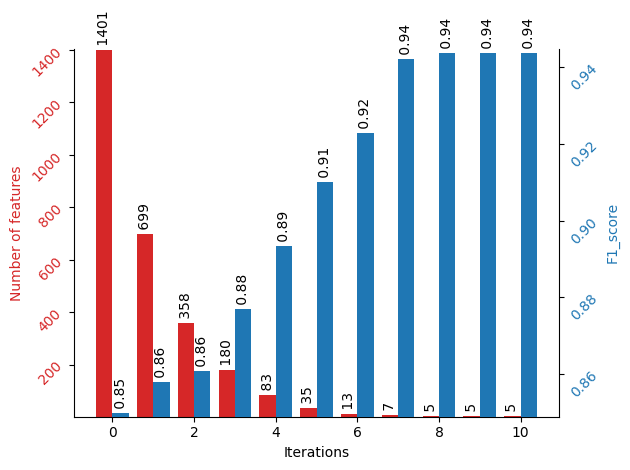

In [12]:
start_time = time.time()
lr_algo = KNeighborsClassifier(n_neighbors=2)
iterarions,features,scores = cafs(covering_array,X_cacao,y_cacao,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cacao_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.7428937129006083, iteration:0, numbers features selected =9,best features selected=Edge Red, EXGR, VEG, RGBVI, NDVI, DVI, EVI, NDRE, RERVI
best f1 score= 0.740047443200288, iteration:1, numbers features selected =8,best features selected=Edge Red, EXGR, VEG, RGBVI, NDVI, DVI, NDRE, RERVI
best f1 score= 0.7500585634258129, iteration:2, numbers features selected =7,best features selected=Edge Red, EXGR, VEG, RGBVI, NDVI, DVI, RERVI
best f1 score= 0.7477139421526717, iteration:3, numbers features selected =6,best features selected=Edge Red, EXGR, VEG, RGBVI, NDVI, DVI
best f1 score= 0.7477139421526717, iteration:4, numbers features selected =6,best features selected=Edge Red, EXGR, VEG, RGBVI, NDVI, DVI
best f1 score= 0.7477139421526717, iteration:5, numbers features selected =6,best features selected=Edge Red, EXGR, VEG, RGBVI, NDVI, DVI
best f1 score= 0.7477139421526717, iteration:6, numbers features selected =6,best features selected=Edge Red, EXGR, VEG, RGBVI, NDVI, D

<Figure size 1100x1000 with 0 Axes>

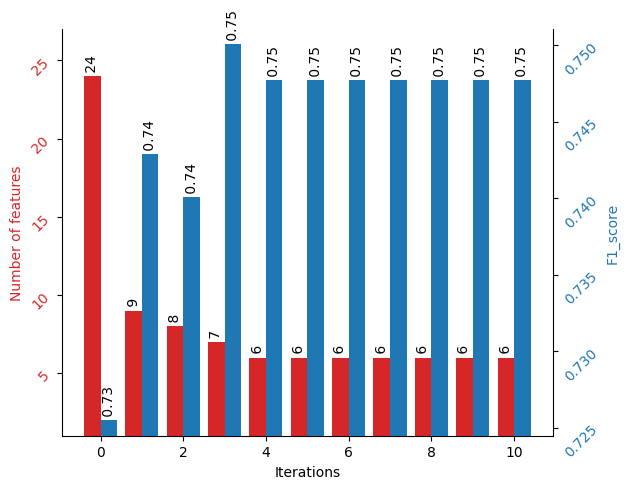

In [17]:
start_time = time.time()
lr_algo = KNeighborsClassifier(n_neighbors=3)
iterarions,features,scores = cafs(covering_array,X_algarrobo,y_algarrobo,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\algarrobo_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['N' 'P']


C:\Users\robma\AppData\Local\Temp\ipykernel_17420\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_17420\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_uma

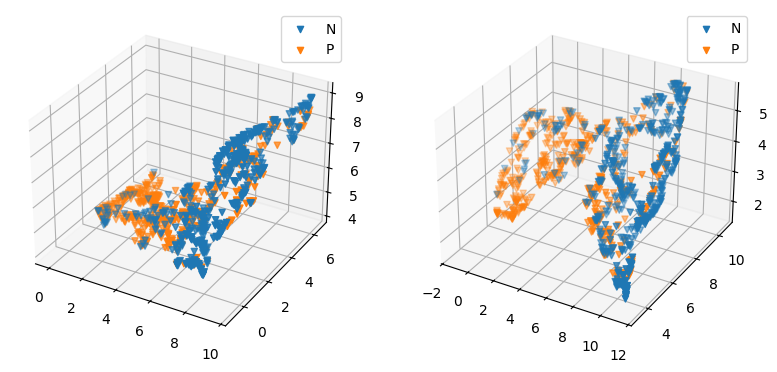

In [12]:
plot_original_vs_reduced_umap(X_algarrobo[['Edge Red', 'EXGR', 'VEG', 'RGBVI', 'NDVI', 'DVI']],X_algarrobo,y_algarrobo,unique_names_algarrobo)

best f1 score= 0.9698757615292537, iteration:0, numbers features selected =6,best features selected=X, Y, X10, X20, Y30, Y40
best f1 score= 0.9843963492206788, iteration:1, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9843963492206788, iteration:2, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9843963492206788, iteration:3, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9843963492206788, iteration:4, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9843963492206788, iteration:5, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9843963492206788, iteration:6, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9843963492206788, iteration:7, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9843963492206788, iteration:8, numbers features selec

<Figure size 1100x1000 with 0 Axes>

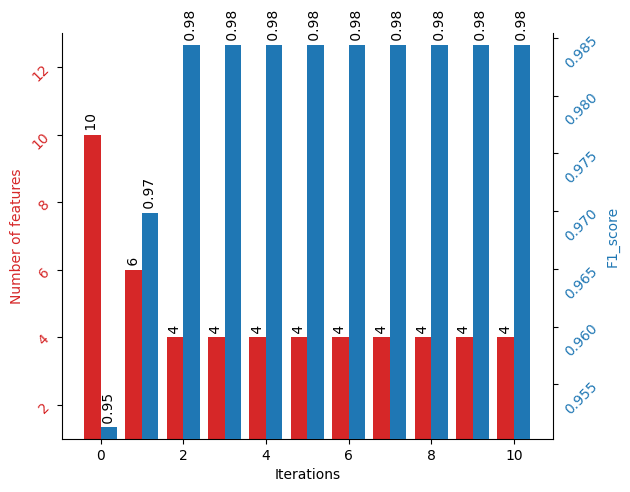

In [10]:
start_time = time.time()
lr_algo = KNeighborsClassifier(n_neighbors=2)
iterarions,features,scores = cafs(covering_array,X_cis,y_cis,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cis_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.9528589993364125, iteration:0, numbers features selected =111,best features selected=910.907, 914.767, 922.487, 934.067, 941.787, 953.367, 961.087, 964.947, 980.387, 984.247, 988.107, 991.967, 999.687, 1003.547, 1007.407, 1022.847, 1038.287, 1046.007, 1049.867, 1092.327, 1115.487, 1123.207, 1134.786, 1138.646, 1142.506, 1157.946, 1161.806, 1165.666, 1173.386, 1177.246, 1184.966, 1192.686, 1196.546, 1200.406, 1204.266, 1208.126, 1219.706, 1231.286, 1235.146, 1246.726, 1254.446, 1258.306, 1266.026, 1269.886, 1281.466, 1289.186, 1296.906, 1304.626, 1312.346, 1331.646, 1339.366, 1354.806, 1358.666, 1366.386, 1370.246, 1374.106, 1377.966, 1385.686, 1404.985, 1408.845, 1412.705, 1420.425, 1432.005, 1435.865, 1447.445, 1470.605, 1474.465, 1478.325, 1486.045, 1489.905, 1493.765, 1501.485, 1505.345, 1509.205, 1513.065, 1524.645, 1528.505, 1532.365, 1543.945, 1547.805, 1555.525, 1559.385, 1563.245, 1567.105, 1574.825, 1582.545, 1586.405, 1597.985, 1609.565, 1636.585, 1640.445, 1

<Figure size 1100x1000 with 0 Axes>

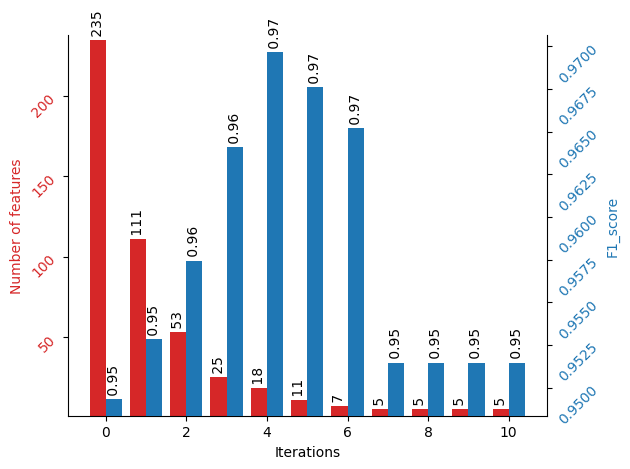

In [11]:
start_time = time.time()
lr_algo = KNeighborsClassifier(n_neighbors=2)
iterarions,features,scores = cafs(covering_array,X_fruit_puree,y_fruit_puree,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\fruit_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.9663694366635542, iteration:0, numbers features selected =211,best features selected=1011.138, 1016.9265, 1022.715, 1024.6445, 1028.5035, 1030.433, 1034.292, 1043.9405, 1047.7995, 1051.6585, 1057.447, 1061.306, 1063.2355, 1074.8135, 1076.743, 1084.461, 1088.32, 1090.2495, 1097.9675, 1101.8265, 1103.756, 1105.6855, 1111.475, 1113.4045, 1115.334, 1117.2635, 1119.193, 1124.9815, 1128.8405, 1130.77, 1134.63, 1138.489, 1142.348, 1144.2775, 1146.207, 1148.1365, 1151.9955, 1157.784, 1163.5725, 1165.502, 1169.362, 1171.2915, 1175.1505, 1177.08, 1179.0095, 1184.798, 1192.517, 1194.4465, 1196.376, 1200.235, 1204.094, 1206.0235, 1211.812, 1213.7415, 1221.4595, 1223.389, 1225.3195, 1227.249, 1233.0375, 1234.967, 1236.8965, 1242.685, 1244.6145, 1248.4745, 1250.404, 1256.1925, 1260.0515, 1263.9105, 1275.4875, 1281.276, 1290.9245, 1292.854, 1294.7835, 1298.6425, 1300.572, 1306.3615, 1308.291, 1312.15, 1314.0795, 1316.009, 1317.9385, 1329.5155, 1331.445, 1333.3745, 1335.304, 1343.023,

<Figure size 1100x1000 with 0 Axes>

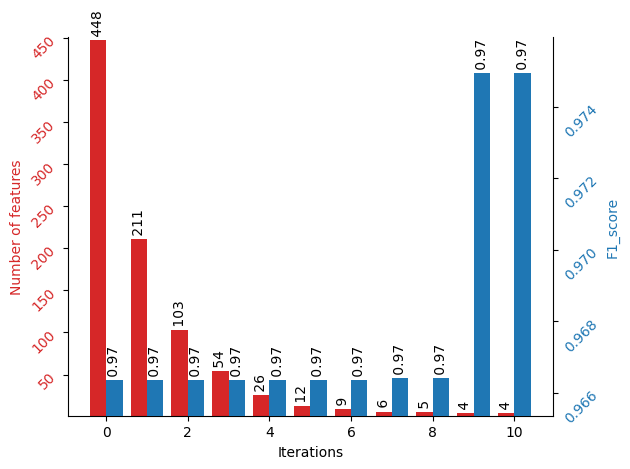

In [12]:
start_time = time.time()
lr_algo = KNeighborsClassifier(n_neighbors=2)
iterarions,features,scores = cafs(covering_array,X_meat,y_meat,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\meat_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.8988098309499237, iteration:0, numbers features selected =270,best features selected=798.892, 810.469, 816.2575, 820.1165, 822.046, 823.9755, 825.905, 835.5525, 841.341, 843.2705, 845.2, 847.1295, 852.918, 854.8475, 862.5655, 866.4245, 868.354, 872.213, 874.1425, 876.072, 885.7195, 887.649, 889.5785, 891.508, 893.4375, 903.085, 908.8735, 910.803, 916.5915, 924.3095, 926.239, 928.1685, 930.098, 933.957, 935.8865, 939.7455, 941.675, 943.6045, 945.534, 947.4645, 951.3235, 955.1825, 959.0415, 960.971, 966.7595, 972.548, 974.4775, 982.1955, 984.125, 987.984, 995.702, 997.6315, 999.561, 1005.3495, 1007.279, 1013.0675, 1016.9265, 1022.715, 1024.6445, 1026.574, 1030.433, 1032.3625, 1040.0815, 1045.87, 1051.6585, 1053.588, 1057.447, 1059.3765, 1063.2355, 1072.883, 1076.743, 1080.602, 1086.3905, 1090.2495, 1092.179, 1103.756, 1105.6855, 1113.4045, 1117.2635, 1119.193, 1126.911, 1130.77, 1132.7005, 1134.63, 1140.4185, 1142.348, 1144.2775, 1146.207, 1151.9955, 1155.8545, 1157.784,

<Figure size 1100x1000 with 0 Axes>

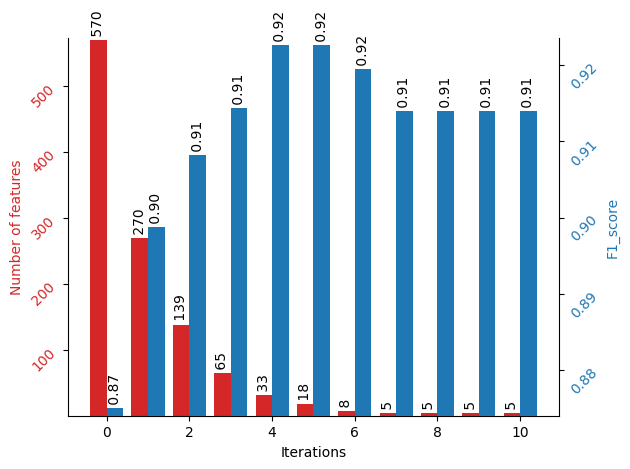

In [13]:
start_time = time.time()
lr_algo = KNeighborsClassifier(n_neighbors=2)
iterarions,features,scores = cafs(covering_array,X_olive,y_olive,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\olive_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

# CAFS OPF

In [ ]:
start_time = time.time()
iterarions,features,scores = cafs(covering_array,X_algarrobo,y_algarrobo,10,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\algarrobo_opf_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

CAFS OPF CV Algarrobo

In [ ]:
#clf = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
#res = cross_val_score(clf,X.values, y_algarrobo.values.ravel(), cv=5,scoring = 'f1_macro')
#print(f"5-CV Algarronoao nibs mean:{res.mean()} , 5-CV Algarrobo STD:{res.std()}" )

from sklearn.model_selection import KFold

scores = []
kf = KFold(n_splits=5,shuffle=True, random_state =42)
X = X_algarrobo[['NGRDI', 'GBRI.1', 'MGRVI', 'DVI', 'REVI', 'REDVI']]

for i, (train_index, test_index) in enumerate(kf.split(X.values)):
   
   x_fold_train = X.values[train_index,:]
   y_fold_train = y_algarrobo.values[train_index]

   x_fold_test =  X.values[test_index,:]
   y_fold_test = y_algarrobo.values[test_index]
   
   clf = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
   clf.fit(x_fold_train, y_fold_train)
   y_pred_fold = clf.predict(x_fold_test)
   score = f1_score(y_fold_test, y_pred_fold,average='macro')
   scores.append(score)

res = np.asarray(scores, dtype=np.float32)
print(f"5-CV Algarrobo OPF mean:{res.mean()} , 5-CV Algarrobo STD:{res.std()}" )



In [ ]:
start_time = time.time()
iterarions,features,scores = cafs(covering_array,X_cacao,y_cacao,10,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cacao_opf_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

5-CV CAFS CACAO OPF

In [ ]:
from sklearn.model_selection import KFold

scores = []
kf = KFold(n_splits=5, shuffle=True, random_state =42)
X = X_cacao[['1121', '1223', '1317', '1734', '1907']]

for i, (train_index, test_index) in enumerate(kf.split(X.values)):
   
   x_fold_train = X.values[train_index,:]
   y_fold_train = y_cacao.values[train_index]

   x_fold_test =  X.values[test_index,:]
   y_fold_test = y_cacao.values[test_index]
   clf = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
   clf.fit(x_fold_train, y_fold_train)
   y_pred_fold = clf.predict(x_fold_test)
   score = f1_score(y_fold_test, y_pred_fold,average='macro')
   scores.append(score)

res = np.asarray(scores, dtype=np.float32)
print(f"5-CV Cacao OPF mean:{res.mean()} , 5-CV Cacao STD:{res.std()}" )

Build Covering Array for CIS CAFS Problem

In [18]:

from testflows.combinatorics import Covering

items = []
paramter_to_test = {"X":[0,1],"Y":[0,1,2],"X10":[0,1,3],"Y10":[0,1,6]}
generate_covering_array = Covering(paramter_to_test, strength=2)
for row in generate_covering_array.array:
   items_2 =[]
   for(key,value) in row.items():
        items_2.append(value)
   items.append(items_2)
ca_for_cis =  np.array(items)
ca_for_cis

array([[0, 0, 3, 6],
       [0, 1, 1, 1],
       [0, 2, 0, 0],
       [1, 0, 1, 0],
       [1, 1, 3, 6],
       [1, 2, 3, 1],
       [1, 0, 0, 1],
       [0, 1, 0, 6],
       [0, 2, 1, 6],
       [0, 1, 3, 0]])

In [ ]:

start_time = time.time()
iterarions,features,scores = cafs(ca_for_cis,X_cis,y_cis,3,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cis_opf_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

In [ ]:
from sklearn.model_selection import KFold

scores = []
kf = KFold(n_splits=5, shuffle=True, random_state =42)
X = X_cis[['Y', 'Y40']]

for i, (train_index, test_index) in enumerate(kf.split(X.values)):
   
   x_fold_train = X.values[train_index,:]
   y_fold_train = y_cis.values[train_index]

   x_fold_test =  X.values[test_index,:]
   y_fold_test = y_cis.values[test_index]
   clf = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
   clf.fit(x_fold_train, y_fold_train)
   y_pred_fold = clf.predict(x_fold_test)
   score = f1_score(y_fold_test, y_pred_fold,average='macro')
   scores.append(score)

res = np.asarray(scores, dtype=np.float32)
print(f"5-CV Cacao OPF mean:{res.mean()} , 5-CV Cacao STD:{res.std()}" )

# CAFS SVC 

best f1 score= 0.675423401366624, iteration:0, numbers features selected =699,best features selected=1101, 1102, 1103, 1104, 1106, 1108, 1109, 1113, 1116, 1123, 1124, 1126, 1128, 1129, 1131, 1132, 1136, 1138, 1139, 1140, 1141, 1142, 1148, 1151, 1152, 1154, 1156, 1159, 1160, 1164, 1167, 1168, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176, 1178, 1179, 1180, 1181, 1182, 1184, 1187, 1189, 1190, 1193, 1194, 1196, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1210, 1211, 1212, 1214, 1217, 1219, 1220, 1223, 1225, 1226, 1227, 1228, 1230, 1232, 1233, 1236, 1240, 1241, 1242, 1243, 1244, 1245, 1246, 1250, 1254, 1257, 1258, 1262, 1263, 1266, 1267, 1268, 1269, 1271, 1273, 1274, 1279, 1282, 1283, 1285, 1288, 1290, 1291, 1292, 1293, 1294, 1297, 1299, 1300, 1302, 1310, 1313, 1314, 1315, 1318, 1319, 1321, 1326, 1328, 1330, 1331, 1333, 1335, 1337, 1338, 1339, 1340, 1344, 1348, 1349, 1350, 1352, 1354, 1355, 1356, 1357, 1360, 1362, 1363, 1364, 1366, 1368, 1370, 1371, 1372, 1373, 1374, 1375, 1376, 1377,

<Figure size 1100x1000 with 0 Axes>

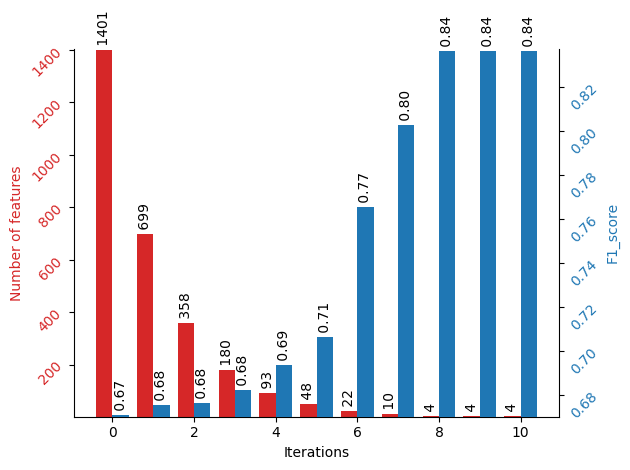

In [15]:
start_time = time.time()
lr_algo = svm.SVC()
iterarions,features,scores = cafs(covering_array,X_cacao,y_cacao,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cacao_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.7472856662121755, iteration:0, numbers features selected =10,best features selected=G, B, Edge Red, NIR, EXGR, NGBDI, RGRI, VEG, NDVI, REDVI
best f1 score= 0.7516098663481436, iteration:1, numbers features selected =6,best features selected=G, Edge Red, NIR, NGBDI, RGRI, VEG
best f1 score= 0.7572140568042671, iteration:2, numbers features selected =3,best features selected=NIR, NGBDI, VEG
best f1 score= 0.7572140568042671, iteration:3, numbers features selected =3,best features selected=NIR, NGBDI, VEG
best f1 score= 0.7572140568042671, iteration:4, numbers features selected =3,best features selected=NIR, NGBDI, VEG
best f1 score= 0.7572140568042671, iteration:5, numbers features selected =3,best features selected=NIR, NGBDI, VEG
best f1 score= 0.7572140568042671, iteration:6, numbers features selected =3,best features selected=NIR, NGBDI, VEG
best f1 score= 0.7572140568042671, iteration:7, numbers features selected =3,best features selected=NIR, NGBDI, VEG
best f1 sco

<Figure size 1100x1000 with 0 Axes>

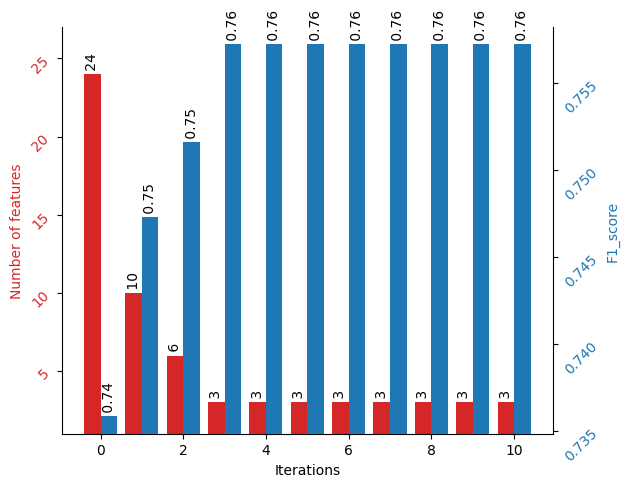

In [14]:
start_time = time.time()
lr_algo = svm.SVC()
iterarions,features,scores = cafs(covering_array,X_algarrobo,y_algarrobo,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\algarrobo_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.9759851337865222, iteration:0, numbers features selected =6,best features selected=X, Y, X10, X20, Y30, Y40
best f1 score= 0.9775878322528507, iteration:1, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9775878322528507, iteration:2, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9775878322528507, iteration:3, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9775878322528507, iteration:4, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9775878322528507, iteration:5, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9775878322528507, iteration:6, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9775878322528507, iteration:7, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9775878322528507, iteration:8, numbers features selec

<Figure size 1100x1000 with 0 Axes>

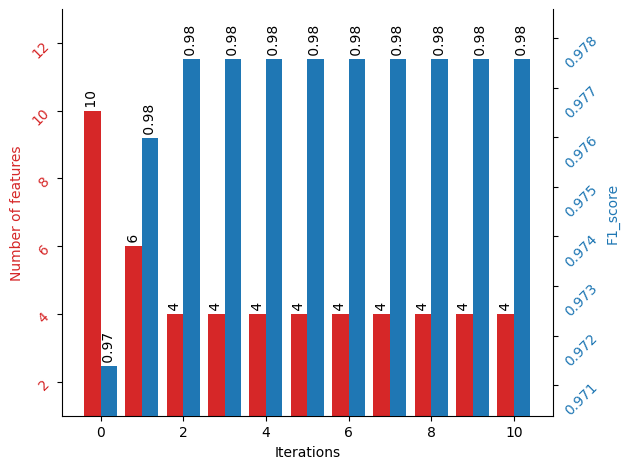

In [17]:
start_time = time.time()
lr_algo = svm.SVC()
iterarions,features,scores = cafs(covering_array,X_cis,y_cis,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cis_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.9830687830687831, iteration:0, numbers features selected =237,best features selected=1005.3495, 1007.279, 1013.0675, 1014.997, 1016.9265, 1022.715, 1024.6445, 1028.5035, 1030.433, 1032.3625, 1034.292, 1038.151, 1042.011, 1043.9405, 1051.6585, 1057.447, 1070.9535, 1072.883, 1076.743, 1080.602, 1082.5315, 1086.3905, 1088.32, 1096.038, 1099.897, 1101.8265, 1103.756, 1105.6855, 1107.615, 1119.193, 1124.9815, 1126.911, 1130.77, 1134.63, 1140.4185, 1142.348, 1150.066, 1155.8545, 1157.784, 1159.7135, 1161.643, 1163.5725, 1165.502, 1167.4325, 1169.362, 1171.2915, 1173.221, 1177.08, 1179.0095, 1180.939, 1182.8685, 1184.798, 1188.657, 1194.4465, 1198.3055, 1200.235, 1206.0235, 1207.953, 1211.812, 1221.4595, 1223.389, 1225.3195, 1227.249, 1229.1785, 1231.108, 1233.0375, 1236.8965, 1238.826, 1240.7555, 1244.6145, 1252.3335, 1256.1925, 1258.122, 1263.9105, 1267.7695, 1269.699, 1271.6285, 1273.558, 1277.417, 1281.276, 1283.2065, 1288.995, 1296.713, 1298.6425, 1300.572, 1302.5015, 13

<Figure size 1100x1000 with 0 Axes>

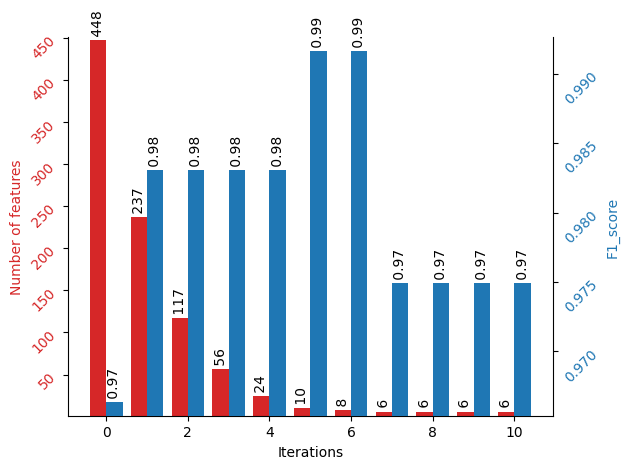

In [18]:
start_time = time.time()
lr_algo = svm.SVC()
iterarions,features,scores = cafs(covering_array,X_meat,y_meat,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\meat_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.9530140346221454, iteration:0, numbers features selected =117,best features selected=903.187, 907.047, 914.767, 918.627, 922.487, 926.347, 930.207, 937.927, 945.647, 953.367, 957.227, 968.807, 980.387, 984.247, 999.687, 1003.547, 1011.267, 1026.707, 1030.567, 1034.427, 1046.007, 1049.867, 1061.447, 1069.167, 1084.607, 1088.467, 1092.327, 1100.047, 1103.907, 1119.347, 1130.927, 1142.506, 1146.366, 1154.086, 1157.946, 1165.666, 1184.966, 1192.686, 1200.406, 1211.986, 1219.706, 1223.566, 1246.726, 1250.586, 1266.026, 1273.746, 1277.606, 1293.046, 1300.766, 1304.626, 1308.486, 1320.066, 1323.926, 1327.786, 1331.646, 1335.506, 1343.226, 1350.946, 1354.806, 1362.526, 1370.246, 1377.966, 1381.826, 1385.686, 1389.545, 1397.265, 1408.845, 1420.425, 1424.285, 1432.005, 1435.865, 1443.585, 1447.445, 1451.305, 1462.885, 1478.325, 1482.185, 1486.045, 1493.765, 1501.485, 1505.345, 1516.925, 1520.785, 1536.225, 1540.085, 1543.945, 1551.665, 1563.245, 1567.105, 1570.965, 1582.545, 158

<Figure size 1100x1000 with 0 Axes>

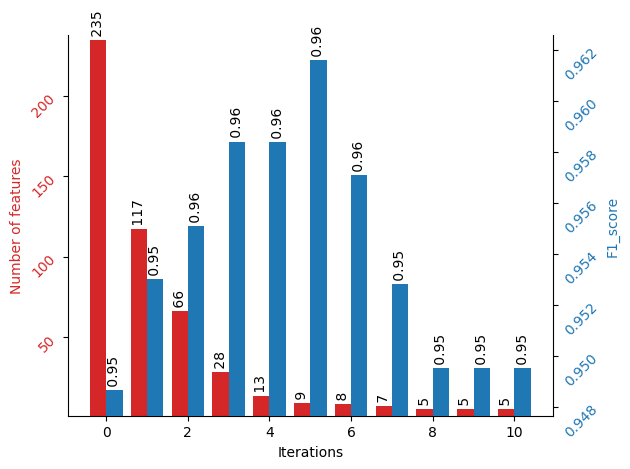

In [19]:
start_time = time.time()
lr_algo = svm.SVC()
iterarions,features,scores = cafs(covering_array,X_fruit_puree,y_fruit_puree,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\fruit_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.8456314804569953, iteration:0, numbers features selected =275,best features selected=800.8215, 802.751, 806.61, 808.5395, 810.469, 816.2575, 823.9755, 825.905, 827.8345, 839.4115, 845.2, 849.059, 850.9885, 852.918, 854.8475, 864.495, 870.2835, 872.213, 874.1425, 876.072, 881.8605, 883.79, 891.508, 895.367, 897.2965, 901.1555, 903.085, 905.0145, 914.662, 916.5915, 918.521, 920.4505, 922.38, 932.0275, 937.816, 939.7455, 945.534, 953.253, 955.1825, 957.112, 959.0415, 962.9005, 964.83, 968.689, 970.6185, 972.548, 974.4775, 976.407, 980.266, 984.125, 987.984, 989.9135, 995.702, 1001.4905, 1003.42, 1011.138, 1013.0675, 1016.9265, 1022.715, 1024.6445, 1026.574, 1032.3625, 1034.292, 1040.0815, 1043.9405, 1051.6585, 1053.588, 1055.5175, 1059.3765, 1061.306, 1069.024, 1074.8135, 1080.602, 1082.5315, 1086.3905, 1088.32, 1092.179, 1101.8265, 1105.6855, 1109.5455, 1115.334, 1119.193, 1121.1225, 1132.7005, 1134.63, 1142.348, 1144.2775, 1146.207, 1153.925, 1157.784, 1159.7135, 1161.6

<Figure size 1100x1000 with 0 Axes>

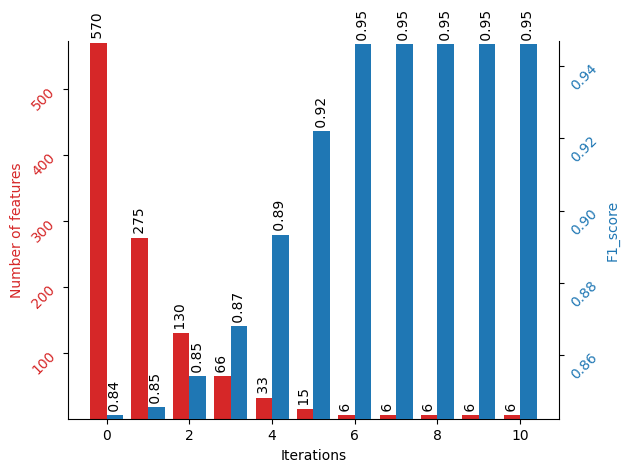

In [20]:
start_time = time.time()
lr_algo = svm.SVC()
iterarions,features,scores = cafs(covering_array,X_olive,y_olive,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\olive_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

# CAFS MLP

best f1 score= 0.9805954060938781, iteration:0, numbers features selected =699,best features selected=1101, 1102, 1103, 1104, 1105, 1107, 1109, 1111, 1112, 1115, 1118, 1119, 1123, 1124, 1126, 1130, 1131, 1132, 1135, 1136, 1139, 1141, 1145, 1146, 1147, 1149, 1150, 1154, 1157, 1160, 1161, 1163, 1164, 1166, 1171, 1173, 1175, 1178, 1180, 1181, 1187, 1188, 1192, 1194, 1195, 1199, 1201, 1202, 1203, 1206, 1207, 1208, 1209, 1210, 1213, 1215, 1217, 1219, 1221, 1222, 1223, 1224, 1226, 1229, 1232, 1233, 1235, 1236, 1238, 1239, 1240, 1243, 1247, 1248, 1249, 1251, 1253, 1254, 1257, 1258, 1262, 1263, 1264, 1266, 1269, 1270, 1271, 1274, 1275, 1277, 1278, 1280, 1282, 1284, 1290, 1293, 1298, 1299, 1300, 1302, 1303, 1306, 1307, 1309, 1310, 1311, 1316, 1317, 1318, 1319, 1322, 1325, 1327, 1328, 1329, 1332, 1333, 1338, 1339, 1341, 1342, 1343, 1344, 1349, 1351, 1352, 1354, 1355, 1356, 1357, 1358, 1362, 1363, 1364, 1366, 1367, 1371, 1374, 1382, 1383, 1386, 1388, 1389, 1399, 1401, 1403, 1407, 1409, 1410, 1415

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (8000) reached and the optimization hasn't converged yet.
  warnings.warn(


best f1 score= 0.9149919550502332, iteration:7, numbers features selected =14,best features selected=1124, 1213, 1310, 1339, 1399, 1492, 1494, 1624, 1736, 1743, 1953, 2124, 2456, 2477
best f1 score= 0.7660659022527073, iteration:8, numbers features selected =12,best features selected=1124, 1213, 1310, 1339, 1399, 1492, 1624, 1736, 1743, 1953, 2124, 2477
best f1 score= 0.7226986758214899, iteration:9, numbers features selected =11,best features selected=1124, 1213, 1310, 1339, 1399, 1492, 1736, 1743, 1953, 2124, 2477
Processing time: 24466.602927446365 seconds


<Figure size 1100x1000 with 0 Axes>

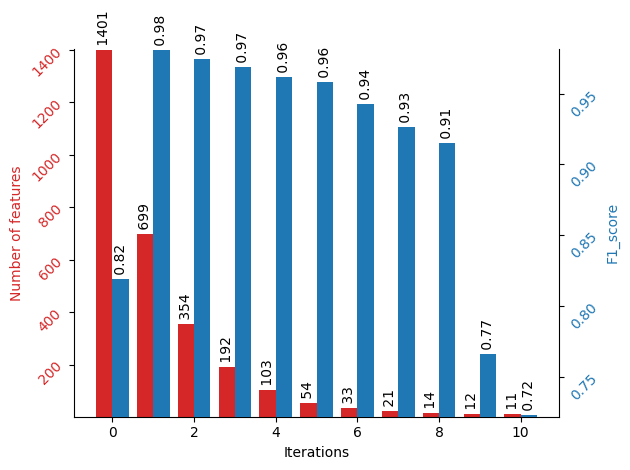

In [11]:
start_time = time.time()
lr_algo = MLPClassifier(solver="sgd", max_iter=8000, shuffle=False)
iterarions,features,scores = cafs(covering_array,X_cacao,y_cacao,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cacao_mlp_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.7368131364092434, iteration:0, numbers features selected =10,best features selected=G, B, NIR, EXG, EXGR, RGRI, VEG, RGBVI, MGRVI, NDRE
best f1 score= 0.7413755541820254, iteration:1, numbers features selected =4,best features selected=G, RGRI, MGRVI, NDRE
best f1 score= 0.7441065945468249, iteration:2, numbers features selected =3,best features selected=G, RGRI, MGRVI
best f1 score= 0.7457188602415581, iteration:3, numbers features selected =2,best features selected=G, MGRVI
best f1 score= 0.7413876960861414, iteration:4, numbers features selected =2,best features selected=G, MGRVI
best f1 score= 0.7425531650365322, iteration:5, numbers features selected =2,best features selected=G, MGRVI
best f1 score= 0.7412612519593915, iteration:6, numbers features selected =2,best features selected=G, MGRVI
best f1 score= 0.7402749756352272, iteration:7, numbers features selected =2,best features selected=G, MGRVI
best f1 score= 0.7402917014161493, iteration:8, numbers features s

<Figure size 1100x1000 with 0 Axes>

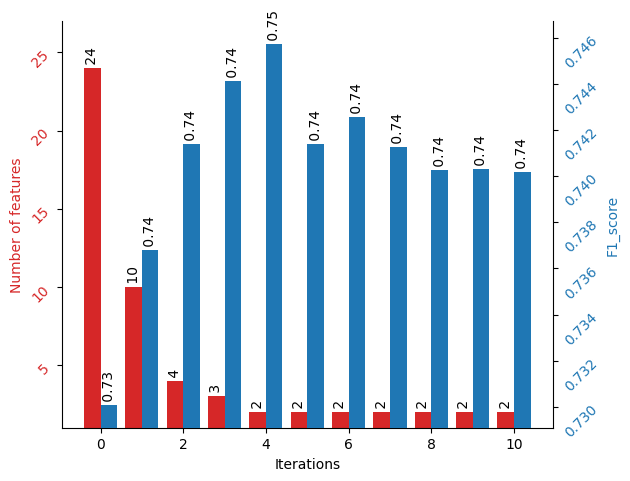

In [10]:
start_time = time.time()
lr_algo = MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)
iterarions,features,scores = cafs(covering_array,X_algarrobo,y_algarrobo,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\algarrobo_mlp_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.951170218938618, iteration:0, numbers features selected =5,best features selected=X, Y10, Y20, Y30, Y40
best f1 score= 0.9515680331810756, iteration:1, numbers features selected =4,best features selected=X, Y10, Y20, Y40
best f1 score= 0.9346650018519979, iteration:2, numbers features selected =3,best features selected=X, Y10, Y20
best f1 score= 0.9341647014305192, iteration:3, numbers features selected =3,best features selected=X, Y10, Y20
best f1 score= 0.9346641263985734, iteration:4, numbers features selected =3,best features selected=X, Y10, Y20
best f1 score= 0.9352637310411188, iteration:5, numbers features selected =3,best features selected=X, Y10, Y20
best f1 score= 0.934064089986232, iteration:6, numbers features selected =3,best features selected=X, Y10, Y20
best f1 score= 0.9355637354196327, iteration:7, numbers features selected =3,best features selected=X, Y10, Y20
best f1 score= 0.9350671008457698, iteration:8, numbers features selected =3,best features 

<Figure size 1100x1000 with 0 Axes>

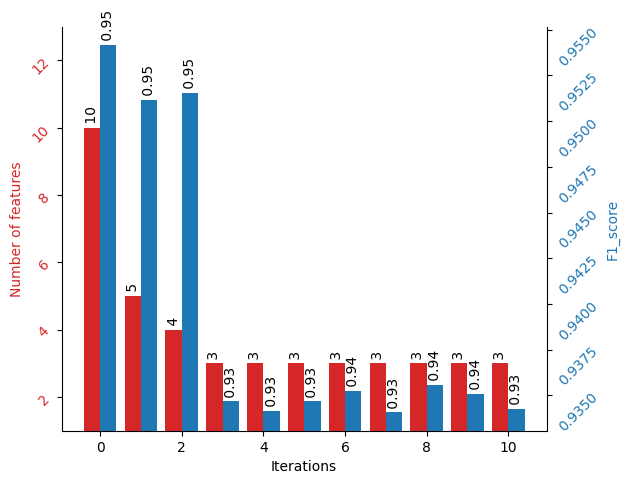

In [11]:
start_time = time.time()
lr_algo = MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)
iterarions,features,scores = cafs(ca_for_cis,X_cis,y_cis,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cis_mlp_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.940816327901417, iteration:0, numbers features selected =122,best features selected=903.187, 907.047, 910.907, 914.767, 922.487, 930.207, 934.067, 949.507, 961.087, 988.107, 991.967, 999.687, 1007.407, 1011.267, 1018.987, 1022.847, 1038.287, 1046.007, 1049.867, 1053.727, 1057.587, 1061.447, 1084.607, 1096.187, 1100.047, 1107.767, 1115.487, 1127.067, 1130.927, 1146.366, 1157.946, 1161.806, 1165.666, 1169.526, 1173.386, 1177.246, 1181.106, 1184.966, 1188.826, 1192.686, 1200.406, 1204.266, 1208.126, 1211.986, 1215.846, 1223.566, 1235.146, 1242.866, 1246.726, 1258.306, 1262.166, 1269.886, 1289.186, 1293.046, 1296.906, 1300.766, 1304.626, 1308.486, 1312.346, 1316.206, 1323.926, 1327.786, 1331.646, 1339.366, 1350.946, 1358.666, 1362.526, 1374.106, 1381.826, 1385.686, 1389.545, 1393.405, 1401.125, 1408.845, 1412.705, 1424.285, 1439.725, 1443.585, 1447.445, 1451.305, 1455.165, 1459.025, 1462.885, 1478.325, 1493.765, 1505.345, 1509.205, 1524.645, 1528.505, 1540.085, 1543.945, 1

<Figure size 1100x1000 with 0 Axes>

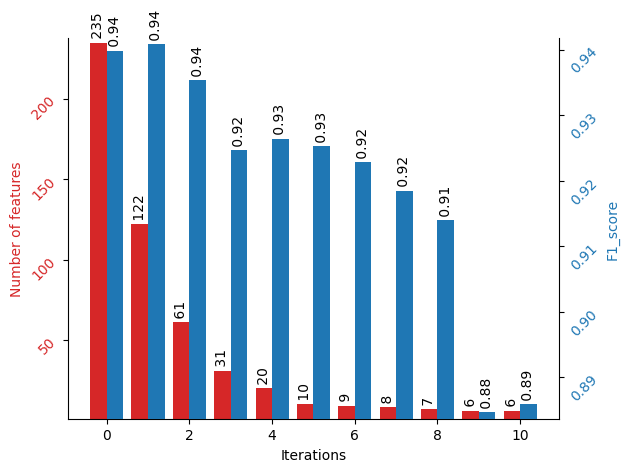

In [8]:
start_time = time.time()
lr_algo = MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)
iterarions,features,scores = cafs(covering_array,X_fruit_puree,y_fruit_puree,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\fruit_pure_mlp_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.9916339869281046, iteration:0, numbers features selected =218,best features selected=1009.2085, 1013.0675, 1014.997, 1020.7855, 1022.715, 1024.6445, 1026.574, 1028.5035, 1030.433, 1032.3625, 1036.2215, 1038.151, 1042.011, 1043.9405, 1045.87, 1051.6585, 1059.3765, 1061.306, 1063.2355, 1074.8135, 1080.602, 1084.461, 1086.3905, 1088.32, 1090.2495, 1099.897, 1105.6855, 1107.615, 1109.5455, 1111.475, 1117.2635, 1119.193, 1126.911, 1130.77, 1132.7005, 1136.5595, 1138.489, 1140.4185, 1150.066, 1151.9955, 1153.925, 1155.8545, 1157.784, 1167.4325, 1173.221, 1175.1505, 1180.939, 1188.657, 1190.5875, 1192.517, 1194.4465, 1198.3055, 1200.235, 1204.094, 1206.0235, 1207.953, 1209.8825, 1211.812, 1215.671, 1219.53, 1223.389, 1225.3195, 1229.1785, 1234.967, 1236.8965, 1244.6145, 1246.544, 1250.404, 1258.122, 1260.0515, 1261.981, 1267.7695, 1269.699, 1275.4875, 1279.3465, 1287.0655, 1288.995, 1290.9245, 1294.7835, 1296.713, 1304.431, 1310.2205, 1316.009, 1317.9385, 1321.7975, 1323.727,

<Figure size 1100x1000 with 0 Axes>

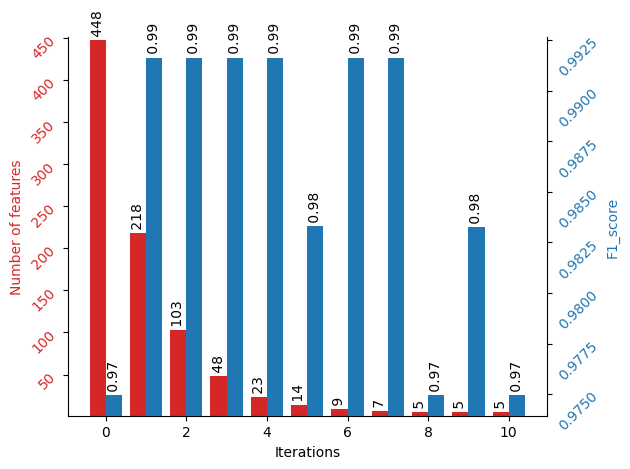

In [9]:
start_time = time.time()
lr_algo = MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)
iterarions,features,scores = cafs(covering_array,X_meat,y_meat,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\meat_mlp_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.9169227994227995, iteration:0, numbers features selected =270,best features selected=798.892, 802.751, 804.6805, 812.3985, 818.187, 823.9755, 825.905, 829.764, 831.6935, 835.5525, 845.2, 849.059, 852.918, 858.7065, 862.5655, 864.495, 876.072, 878.0015, 885.7195, 889.5785, 891.508, 899.226, 903.085, 905.0145, 906.944, 912.7325, 914.662, 916.5915, 918.521, 920.4505, 926.239, 930.098, 932.0275, 935.8865, 939.7455, 943.6045, 945.534, 947.4645, 949.394, 953.253, 959.0415, 964.83, 966.7595, 970.6185, 972.548, 976.407, 978.3365, 980.266, 986.0545, 993.7725, 995.702, 997.6315, 1001.4905, 1005.3495, 1007.279, 1013.0675, 1014.997, 1020.7855, 1022.715, 1024.6445, 1028.5035, 1034.292, 1036.2215, 1038.151, 1043.9405, 1045.87, 1049.729, 1051.6585, 1057.447, 1061.306, 1065.165, 1076.743, 1082.5315, 1092.179, 1094.1085, 1096.038, 1099.897, 1101.8265, 1107.615, 1109.5455, 1113.4045, 1115.334, 1117.2635, 1119.193, 1130.77, 1132.7005, 1134.63, 1136.5595, 1148.1365, 1151.9955, 1153.925, 1

<Figure size 1100x1000 with 0 Axes>

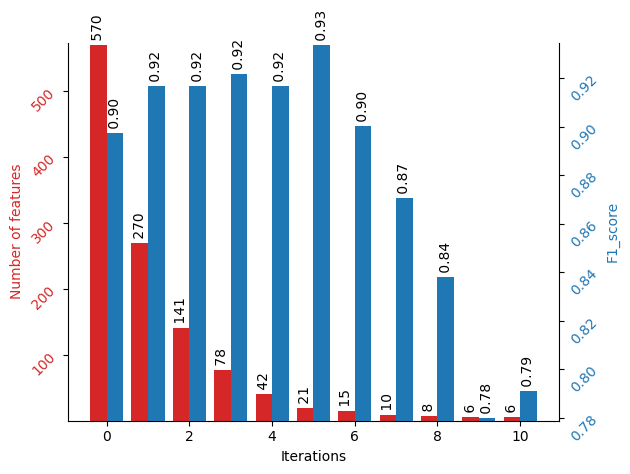

In [10]:
start_time = time.time()
lr_algo = MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)
iterarions,features,scores = cafs(covering_array,X_olive,y_olive,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\olive_mlp_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

In [ ]:
clf = MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)
X = X_cis[['X', 'Y', 'Y30', 'Y40']]
res = cross_val_score(clf,X.values, y_cis.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV CIS mean:{res.mean()} , 5-CV CIS STD:{res.std()}" )